In [6]:
from tensorflow.keras.utils import to_categorical
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
import numpy as np
import matplotlib.pyplot as plt
import re
import pandas as pd


%matplotlib inline
seed = 0
np.random.seed(seed)
import tensorflow as tf
tf.random.set_seed(seed)

import sys
import os
# Add the directory containing callbacks.py to sys.path
sys.path.append(os.path.join(os.getcwd(), "hls4ml-tutorial"))

# Simulate sourcing the script to set variables (as a fallback)
os.environ['XILINX_VITIS'] = '/opt/local/Vitis_HLS/2024.1'  # Adjust this path as needed
# Update the PATH variable
os.environ['PATH'] = os.path.join(os.environ['XILINX_VITIS'], 'bin') + ':' + os.environ.get('PATH', '')

In [23]:
def parse_utilization(report_text):
    """
    Parse the Utilization table to extract DSP, LUT, and BRAM usage.
    
    This function searches for a table row that starts with "|Utilization (%)"
    and then extracts the following columns (after splitting on "|"):
    
      - Column 2: BRAM_18K usage (we call this BRAM)
      - Column 3: DSP usage
      - Column 5: LUT usage
      
    Any occurrence of "~0" is replaced with 0.
    Returns dsp, lut, bram as floats.
    """
    dsp = lut = bram = None
    for line in report_text.splitlines():
        if line.strip().startswith("|Utilization (%)"):
            # Split the line by "|" and remove empty strings/spaces.
            parts = [p.strip() for p in line.split("|") if p.strip()]
            if len(parts) < 6:
                continue
            # Expected order: 
            # parts[0] = "Utilization (%)"
            # parts[1] = BRAM_18K usage
            # parts[2] = DSP usage
            # parts[3] = FF usage (ignored)
            # parts[4] = LUT usage
            # parts[5] = URAM usage (ignored)
            try:
                bram = float(parts[1].replace("~0", "0"))
            except:
                bram = 0.0
            try:
                dsp = float(parts[2].replace("~0", "0"))
            except:
                dsp = 0.0
            try:
                lut = float(parts[4].replace("~0", "0"))
            except:
                lut = 0.0
            break
    return dsp, lut, bram

def parse_latency(report_text):
    """
    Parse the Performance Estimates section to extract the latency (in ns).
    
    The report typically contains a table like:
    
        +---------+---------+-----------+-----------+-----+-----+---------+
        |   Latency (cycles) |   Latency (absolute)  |  Interval | Pipeline|
        |   min   |   max   |    min    |    max    | min | max |   Type  |
        +---------+---------+-----------+-----------+-----+-----+---------+
        |       16|       16|  80.000 ns|  80.000 ns|    1|    1|      yes|
        +---------+---------+-----------+-----------+-----+-----+---------+
    
    This function searches for a header line containing both "Latency (cycles)" 
    and "Latency (absolute)" and then looks for a data row (the next row with "ns").
    It extracts the first occurrence of a latency value (in ns) and returns it as a float.
    """
    lines = report_text.splitlines()
    for i, line in enumerate(lines):
        if "Latency (cycles)" in line and "Latency (absolute)" in line:
            # Now scan subsequent lines
            for j in range(i+1, len(lines)):
                data_line = lines[j].strip()
                # Check that the line starts with "|" and has either "ns" or "us"
                if data_line.startswith("|") and ("ns" in data_line or "us" in data_line):
                    # Split the line by "|" and remove empty strings.
                    parts = [p.strip() for p in data_line.split("|") if p.strip()]
                    
                    # Skip header rows that have text (like "min") instead of numbers.
                    try:
                        # Try converting the first token to a float.
                        float(parts[0])
                    except ValueError:
                        continue  # Likely a header row; skip it.
                    
                    if len(parts) >= 4:
                        # The first "Latency (absolute)" value is in parts[2].
                        latency_token = parts[2]
                        # Check if the value is in microseconds and convert it to ns.
                        if "us" in latency_token:
                            try:
                                latency_val = float(latency_token.replace("us", "").strip()) * 1000
                            except Exception as e:
                                print("Error converting latency value in us:", latency_token, e)
                                return None
                        elif "ns" in latency_token:
                            try:
                                latency_val = float(latency_token.replace("ns", "").strip())
                            except Exception as e:
                                print("Error converting latency value in ns:", latency_token, e)
                                return None
                        else:
                            # No units found; assume the value is already a float.
                            try:
                                latency_val = float(latency_token.strip())
                            except Exception as e:
                                print("Error converting latency value:", latency_token, e)
                                return None
                        return latency_val
            break
    return None

def process_vivado_reports(report_paths, config_labels, accuracy_values):
    """
    Process multiple HLS/Vivado reports and return a pandas DataFrame.
    
    Parameters:
      - report_paths: list of paths to .rpt files.
      - config_labels: list of labels for each configuration (e.g., "Pruning 60%")
      - accuracy_values: list of accuracy values (in %) corresponding to each report
      
    The function extracts:
        • DSP, LUT, and BRAM utilization from the "Utilization (%)" table
        • Latency (in ns) from the Performance Estimates section
        
    The efficiency score is computed as:
    
         Efficiency Score = Accuracy / (DSP + LUT + BRAM + Latency)
    
    (Note: Make sure that your units and formula match your needs.)
    
    Returns a pandas DataFrame with columns:
      - Configuration
      - Accuracy (%)
      - DSP (%)
      - LUT (%)
      - BRAM (%)
      - Latency (ns)
      - Efficiency Score
    """
    if not (len(report_paths) == len(config_labels) == len(accuracy_values)):
        raise ValueError("Length of report_paths, config_labels, and accuracy_values must be the same.")
    
    results = []
    for path, label, accuracy in zip(report_paths, config_labels, accuracy_values):
        try:
            with open(path, "r") as f:
                content = f.read()
        except Exception as e:
            print(f"Error reading {path}: {e}")
            continue
        
        dsp, lut, bram = parse_utilization(content)
        latency = parse_latency(content)
        if dsp is None or lut is None or bram is None or latency is None:
            print(f"Skipping {path} due to parsing error.")
            continue
        
        denominator = dsp + lut + bram + latency
        efficiency = accuracy / denominator if denominator else 0.0
        
        results.append({
            "Configuration": label,
            "Accuracy (%)": accuracy,
            "DSP (%)": dsp,
            "LUT (%)": lut,
            "BRAM (%)": bram,
            "Latency (ns)": latency,
            "Efficiency Score": efficiency
        })
    
    df = pd.DataFrame(results)
    return df

### Pruning

Accuracy 75%:   0.748020634920635

Accuracy 60%:   0.716479365079365

Accuracy 90%:   0.7447920634920635

  Configuration  Accuracy (%)  DSP (%)  LUT (%)  BRAM (%)  Latency (ns)  \
0   Pruning 60%         71.65     17.0      7.0       0.0          80.0   
1   Pruning 75%         74.80     17.0      7.0       0.0          80.0   
2   Pruning 90%         74.48     10.0      2.0       0.0          75.0   

   Efficiency Score  
0          0.688942  
1          0.719231  
2          0.856092  


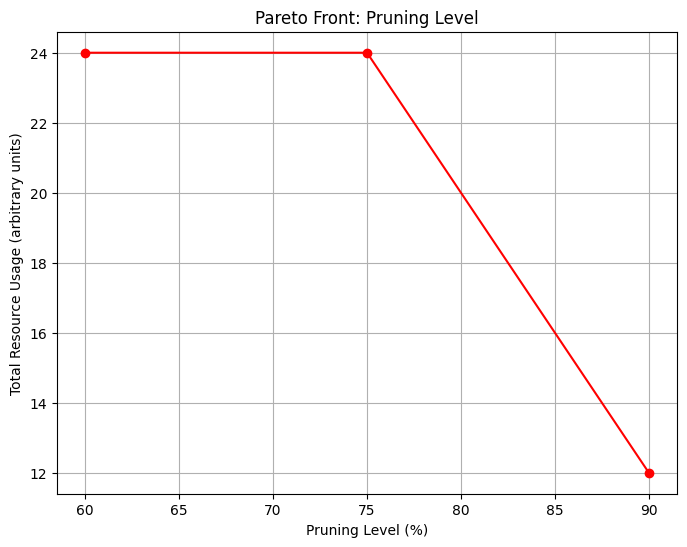

In [34]:
report_paths_prune = [
    "/home/hep/lr1424/hls4ml-tutorial/model_2.1/hls4ml_prj_prune_60/myproject_prj/solution1/syn/report/myproject_csynth.rpt",
    "/home/hep/lr1424/hls4ml-tutorial/model_2/hls4ml_prj_prune_75/myproject_prj/solution1/syn/report/myproject_csynth.rpt",  
    "/home/hep/lr1424/hls4ml-tutorial/model_2.2/hls4ml_prj_prune_90/myproject_prj/solution1/syn/report/myproject_csynth.rpt"
]
config_labels_prune = ["Pruning 60%", "Pruning 75%", "Pruning 90%"]  

accuracy_values_prune = [71.65, 74.80, 74.48]  

df_prune = process_vivado_reports(report_paths_prune, config_labels_prune, accuracy_values_prune)
print(df_prune)


df_prune['pruning'] = df_prune['Configuration'].str.extract(r'Pruning (\d+)%', expand=False).astype(float)
df_prune['Total Resources'] = df_prune['DSP (%)'] + df_prune['LUT (%)'] + df_prune['BRAM (%)']

plt.figure(figsize=(8,6))
plt.plot(df_prune['pruning'], df_prune['Total Resources'],
         marker='o', linestyle='-', color='red')
plt.xlabel('Pruning Level (%)')
plt.ylabel('Total Resource Usage (arbitrary units)')
plt.title('Pareto Front: Pruning Level')
plt.grid(True)
plt.show()

### Reuse Factor

     Configuration  Accuracy (%)  DSP (%)  LUT (%)  BRAM (%)  Latency (ns)  \
0   Reuse Factor 1     18.628889     26.0      9.0       0.0          80.0   
1   Reuse Factor 2     18.652857     25.0      9.0       0.0          85.0   
2  Reuse Factor 10     18.652857      5.0     10.0       0.0         165.0   

   Efficiency Score  
0          0.161990  
1          0.156747  
2          0.103627  


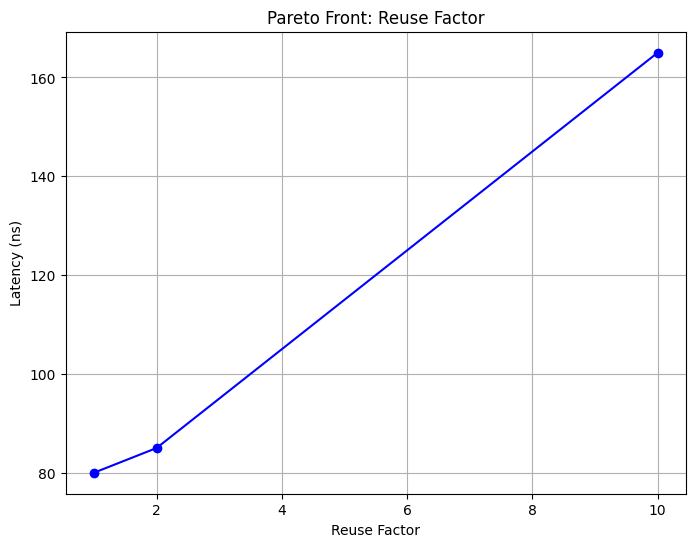

In [35]:
report_paths_reuse = [
    "/home/hep/lr1424/hls4ml-tutorial/model_1/hls4ml_prj/myproject_prj/solution1/syn/report/myproject_csynth.rpt",
    "/home/hep/lr1424/hls4ml-tutorial/model_1/hls4ml_prj_3/myproject_prj/solution1/syn/report/myproject_csynth.rpt",
    "/home/hep/lr1424/hls4ml-tutorial/model_1/hls4ml_prj_4/myproject_prj/solution1/syn/report/myproject_csynth.rpt"
]

config_labels_reuse = ["Reuse Factor 1", "Reuse Factor 2", "Reuse Factor 10"]

accuracy_values_reuse = [
    0.1862888888888889,  # RF = 1
    0.18652857142857143,  # RF = 2
    0.18652857142857143   # RF = 10
]
accuracy_values_reuse = [a * 100 for a in accuracy_values_reuse]  # Convert to percentage

df_reuse = process_vivado_reports(report_paths_reuse, config_labels_reuse, accuracy_values_reuse)

print(df_reuse)

df_reuse['reuse_factor'] = df_reuse['Configuration'].str.extract(r'Reuse Factor (\d+)', expand=False).astype(float)
df_reuse = df_reuse.sort_values('reuse_factor')

plt.figure(figsize=(8,6))
plt.plot(df_reuse['reuse_factor'], df_reuse['Latency (ns)'],
         marker='o', linestyle='-', color='blue')
plt.xlabel('Reuse Factor')
plt.ylabel('Latency (ns)')
plt.title('Pareto Front: Reuse Factor')
plt.grid(True)
plt.show()